In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

In [2]:
df = pd.read_csv("../data/raw/IBM_HR_Analytics_Employee_Attrition.csv")

## Initial Inspection

In [3]:
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [4]:
df.shape

(1470, 35)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [6]:
df.dtypes

Age                          int64
Attrition                   object
BusinessTravel              object
DailyRate                    int64
Department                  object
DistanceFromHome             int64
Education                    int64
EducationField              object
EmployeeCount                int64
EmployeeNumber               int64
EnvironmentSatisfaction      int64
Gender                      object
HourlyRate                   int64
JobInvolvement               int64
JobLevel                     int64
JobRole                     object
JobSatisfaction              int64
MaritalStatus               object
MonthlyIncome                int64
MonthlyRate                  int64
NumCompaniesWorked           int64
Over18                      object
OverTime                    object
PercentSalaryHike            int64
PerformanceRating            int64
RelationshipSatisfaction     int64
StandardHours                int64
StockOptionLevel             int64
TotalWorkingYears   

## Missing Values

In [7]:
df.isnull().sum()

Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSince

## Duplicate Rows

In [8]:
df.duplicated().sum()

0

## Checking Target Variable

In [9]:
df["Attrition"].value_counts()

Attrition
No     1233
Yes     237
Name: count, dtype: int64

In [10]:
df["Attrition"].value_counts(normalize=True) * 100

Attrition
No     83.877551
Yes    16.122449
Name: proportion, dtype: float64

## Descriptive Statistics

Numeric Columns

In [11]:
df.describe()

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,...,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,...,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,...,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


Categorical Columns

In [12]:
df.describe(include="object")

,Attrition,BusinessTravel,Department,EducationField,Gender,JobRole,MaritalStatus,Over18,OverTime
count,1470,1470,1470,1470,1470,1470,1470,1470,1470
unique,2,3,3,6,2,9,3,1,2
top,No,Travel_Rarely,Research & Development,Life Sciences,Male,Sales Executive,Married,Y,No
freq,1233,1043,961,606,882,326,673,1470,1054


## Identifying Constant Columns

In [13]:
for col in df.columns:
    print(col, df[col].nunique())

Age 43
Attrition 2
BusinessTravel 3
DailyRate 886
Department 3
DistanceFromHome 29
Education 5
EducationField 6
EmployeeCount 1
EmployeeNumber 1470
EnvironmentSatisfaction 4
Gender 2
HourlyRate 71
JobInvolvement 4
JobLevel 5
JobRole 9
JobSatisfaction 4
MaritalStatus 3
MonthlyIncome 1349
MonthlyRate 1427
NumCompaniesWorked 10
Over18 1
OverTime 2
PercentSalaryHike 15
PerformanceRating 2
RelationshipSatisfaction 4
StandardHours 1
StockOptionLevel 4
TotalWorkingYears 40
TrainingTimesLastYear 7
WorkLifeBalance 4
YearsAtCompany 37
YearsInCurrentRole 19
YearsSinceLastPromotion 16
YearsWithCurrManager 18


## Visualize Attrition

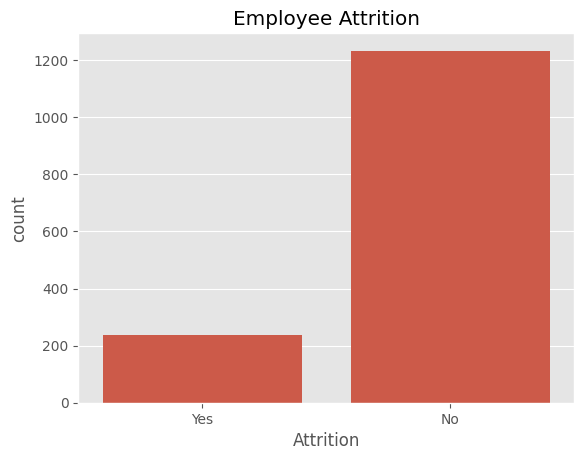

In [14]:
sns.countplot(
    data=df,
    x="Attrition"
)

plt.title("Employee Attrition")
plt.show()

## First Crosstabs

Department

In [15]:
pd.crosstab(
    df["Department"],
    df["Attrition"],
    normalize="index"
) * 100

Attrition,No,Yes
Department,,
Human Resources,80.952381,19.047619
Research & Development,86.160250,13.839750
Sales,79.372197,20.627803


Overtime

In [16]:
pd.crosstab(
    df["OverTime"],
    df["Attrition"],
    normalize="index"
) * 100

Attrition,No,Yes
OverTime,,
No,89.563567,10.436433
Yes,69.471154,30.528846


Job Satisfaction

In [17]:
pd.crosstab(
    df["JobSatisfaction"],
    df["Attrition"],
    normalize="index"
) * 100

Attrition,No,Yes
JobSatisfaction,,
1,77.162630,22.837370
2,83.571429,16.428571
3,83.484163,16.515837
4,88.671024,11.328976


Business Travel

In [18]:
pd.crosstab(
    df["BusinessTravel"],
    df["Attrition"],
    normalize="index"
) * 100

Attrition,No,Yes
BusinessTravel,,
Non-Travel,92.000000,8.000000
Travel_Frequently,75.090253,24.909747
Travel_Rarely,85.043145,14.956855


Job Role

In [19]:
pd.crosstab(
    df["JobRole"],
    df["Attrition"],
    normalize="index"
) * 100

Attrition,No,Yes
JobRole,,
Healthcare Representative,93.129771,6.870229
Human Resources,76.923077,23.076923
Laboratory Technician,76.061776,23.938224
Manager,95.098039,4.901961
Manufacturing Director,93.103448,6.896552
Research Director,97.500000,2.500000
Research Scientist,83.904110,16.095890
Sales Executive,82.515337,17.484663
Sales Representative,60.240964,39.759036


## Numerical Comparisons

Average Age

In [20]:
df.groupby("Attrition")["Age"].mean()

Attrition
No     37.561233
Yes    33.607595
Name: Age, dtype: float64

Monthly Income

In [21]:
df.groupby("Attrition")["MonthlyIncome"].mean()

Attrition
No     6832.739659
Yes    4787.092827
Name: MonthlyIncome, dtype: float64

Years at Company

In [22]:
df.groupby("Attrition")["YearsAtCompany"].mean()

Attrition
No     7.369019
Yes    5.130802
Name: YearsAtCompany, dtype: float64

Total Working Years

In [23]:
df.groupby("Attrition")["TotalWorkingYears"].mean()

Attrition
No     11.862936
Yes     8.244726
Name: TotalWorkingYears, dtype: float64

Distance From Home

In [24]:
df.groupby("Attrition")["DistanceFromHome"].mean()

Attrition
No      8.915653
Yes    10.632911
Name: DistanceFromHome, dtype: float64

## Distribution Plots

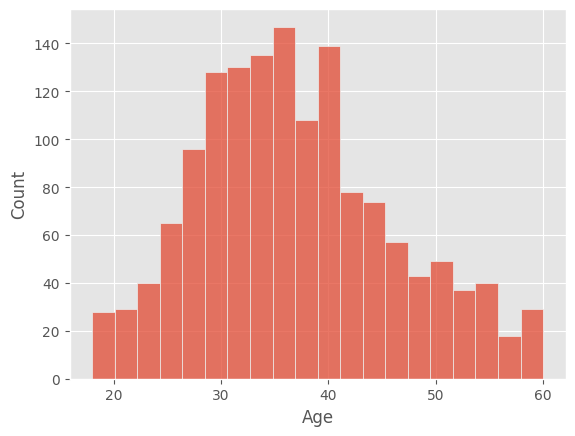

In [25]:
sns.histplot(df["Age"], bins=20)
plt.show()

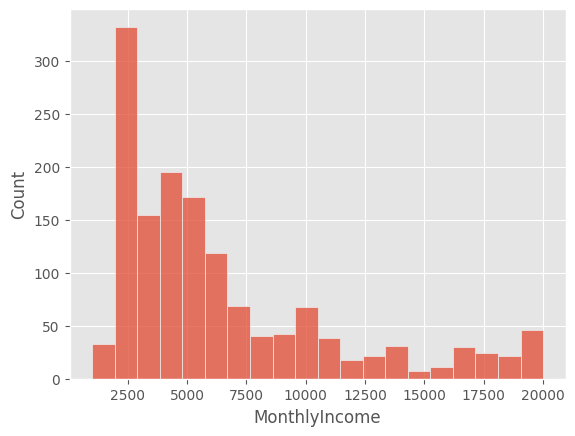

In [26]:
sns.histplot(df["MonthlyIncome"], bins=20)
plt.show()

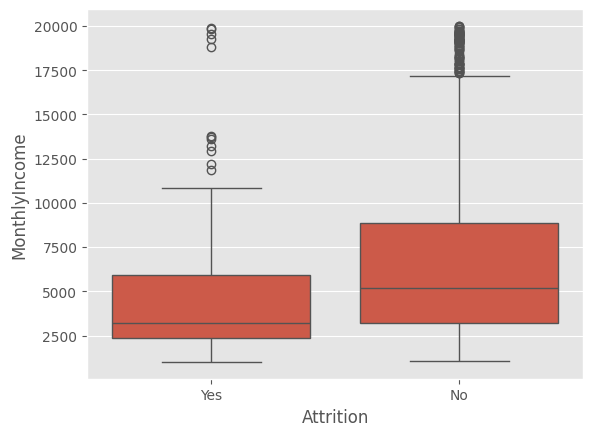

In [27]:
sns.boxplot(
    data=df,
    x="Attrition",
    y="MonthlyIncome"
)

plt.show()

## Saving Clean Dataset

In [28]:
df.to_csv(
    "../data/processed/clean_hr_attrition.csv",
    index=False
)

## Feature Engineering

# 1. Dropping Unnecessary Cloumns

These carry no predictive information because they have only one unique value each:
EmployeeCount
Over18
StandardHours

Although it has unique values, it's just an identifier and should never be used for prediction:
EmployeeNumber

In [29]:
df.drop(
    columns=[
        "EmployeeCount",
        "EmployeeNumber",
        "Over18",
        "StandardHours"
    ],
    inplace=True
)

# 2. Create Age Groups

In [30]:
df["Age Group"] = pd.cut(
    df["Age"],
    bins=[17, 30, 40, 50, 60],
    labels=["18-30", "31-40", "41-50", "51-60"]
)

# 3. Create Income Groups

In [31]:
df["Income Group"] = pd.qcut(
    df["MonthlyIncome"],
    q=4,
    labels=[
        "Low",
        "Lower-Middle",
        "Upper-Middle",
        "High"
    ]
)

# 4. Create Tenure Groups

In [32]:
df["Tenure Group"] = pd.cut(
    df["YearsAtCompany"],
    bins=[-1, 2, 5, 10, 40],
    labels=[
        "0-2",
        "3-5",
        "6-10",
        "10+"
    ]
)

# 5. Create Experience Groups

In [33]:
df["Experience Group"] = pd.cut(
    df["TotalWorkingYears"],
    bins=[-1, 5, 10, 20, 45],
    labels=[
        "0-5",
        "6-10",
        "11-20",
        "20+"
    ]
)

# 6. Verifying New Columns

In [34]:
df.shape

(1470, 35)

In [35]:
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,...,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,Age Group,Income Group,Tenure Group,Experience Group
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,2,Female,...,0,1,6,4,0,5,41-50,Upper-Middle,6-10,6-10
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,3,Male,...,3,3,10,7,1,7,41-50,Upper-Middle,6-10,6-10
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,4,Male,...,3,3,0,0,0,0,31-40,Low,0-2,6-10
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,4,Female,...,3,3,8,7,3,0,31-40,Low,6-10,6-10
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,Male,...,3,3,2,2,2,2,18-30,Lower-Middle,0-2,6-10


# 7. Saving Updated Dataset

In [36]:
df.to_csv(
    "../data/processed/clean_hr_attrition.csv",
    index=False
)

## Section 1 — Attrition by Age Group

In [37]:
pd.crosstab(
    df["Age Group"],
    df["Attrition"],
    normalize="index"
) * 100

Attrition,No,Yes
Age Group,,
18-30,74.093264,25.906736
31-40,86.268174,13.731826
41-50,89.440994,10.559006
51-60,87.412587,12.587413


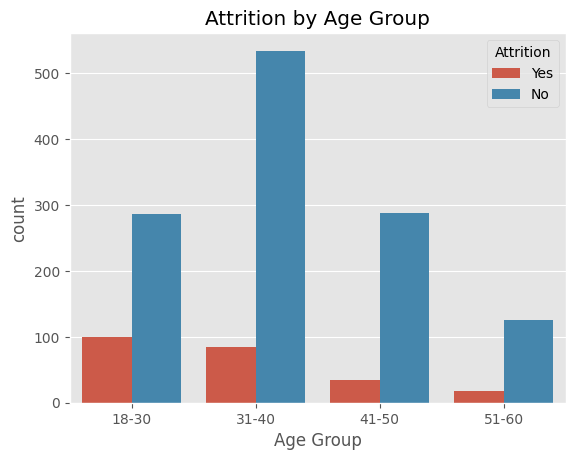

In [38]:
sns.countplot(
    data=df,
    x="Age Group",
    hue="Attrition"
)

plt.title("Attrition by Age Group")
plt.show()

## Section 2 — Attrition by Income Group

In [39]:
pd.crosstab(
    df["Income Group"],
    df["Attrition"],
    normalize="index"
) * 100

Attrition,No,Yes
Income Group,,
Low,70.731707,29.268293
Lower-Middle,85.792350,14.207650
Upper-Middle,89.373297,10.626703
High,89.673913,10.326087


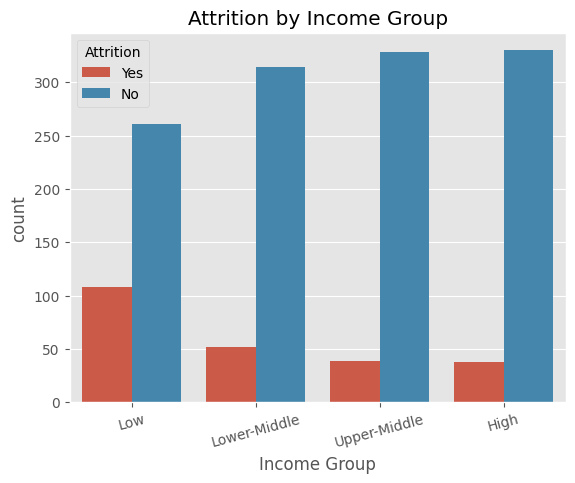

In [40]:
sns.countplot(
    data=df,
    x="Income Group",
    hue="Attrition"
)

plt.title("Attrition by Income Group")
plt.xticks(rotation=15)
plt.show()

## Section 3 — Attrition by Tenure Group

In [41]:
pd.crosstab(
    df["Tenure Group"],
    df["Attrition"],
    normalize="index"
) * 100

Attrition,No,Yes
Tenure Group,,
0-2,70.175439,29.824561
3-5,86.175115,13.824885
6-10,87.723214,12.276786
10+,91.869919,8.130081


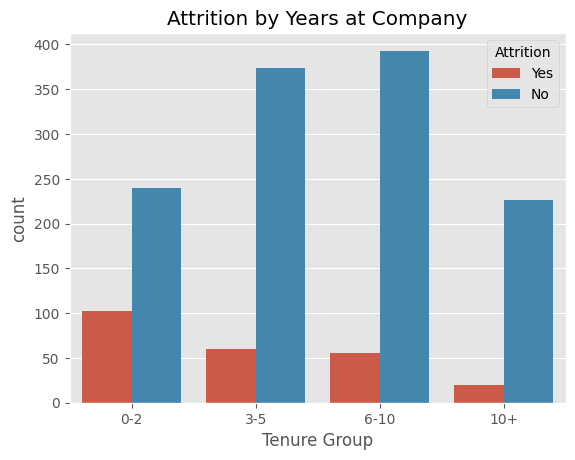

In [42]:
sns.countplot(
    data=df,
    x="Tenure Group",
    hue="Attrition"
)

plt.title("Attrition by Years at Company")
plt.show()

## Section 4 — Attrition by Experience

In [43]:
pd.crosstab(
    df["Experience Group"],
    df["Attrition"],
    normalize="index"
) * 100

Attrition,No,Yes
Experience Group,,
0-5,71.202532,28.797468
6-10,85.008237,14.991763
11-20,88.529412,11.470588
20+,92.270531,7.729469


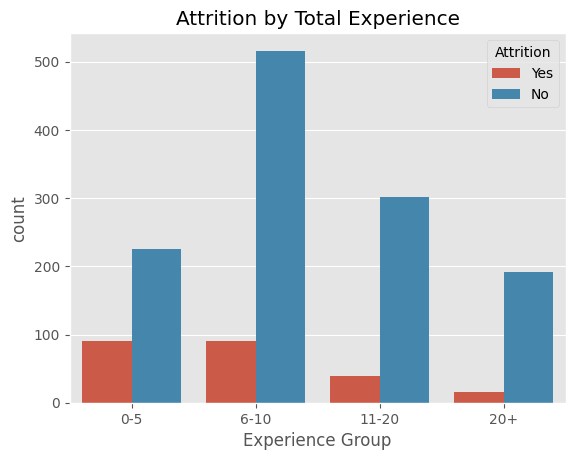

In [44]:
sns.countplot(
    data=df,
    x="Experience Group",
    hue="Attrition"
)

plt.title("Attrition by Total Experience")
plt.show()

## Section 5 — Attrition by Gender

In [45]:
pd.crosstab(
    df["Gender"],
    df["Attrition"],
    normalize="index"
) * 100

Attrition,No,Yes
Gender,,
Female,85.204082,14.795918
Male,82.993197,17.006803


## Section 6 — Attrition by Marital Status

In [46]:
pd.crosstab(
    df["MaritalStatus"],
    df["Attrition"],
    normalize="index"
) * 100

Attrition,No,Yes
MaritalStatus,,
Divorced,89.908257,10.091743
Married,87.518574,12.481426
Single,74.468085,25.531915


## Section 7 — Attrition by Education

In [47]:
pd.crosstab(
    df["Education"],
    df["Attrition"],
    normalize="index"
) * 100

Attrition,No,Yes
Education,,
1,81.764706,18.235294
2,84.397163,15.602837
3,82.692308,17.307692
4,85.427136,14.572864
5,89.583333,10.416667


## Section 8 — Attrition by Education Field

In [48]:
pd.crosstab(
    df["EducationField"],
    df["Attrition"],
    normalize="index"
) * 100

Attrition,No,Yes
EducationField,,
Human Resources,74.074074,25.925926
Life Sciences,85.313531,14.686469
Marketing,77.987421,22.012579
Medical,86.422414,13.577586
Other,86.585366,13.414634
Technical Degree,75.757576,24.242424


## Section 9 — Satisfaction Analysis

In [49]:
pd.crosstab(
    df["EnvironmentSatisfaction"],
    df["Attrition"],
    normalize="index"
) * 100

Attrition,No,Yes
EnvironmentSatisfaction,,
1,74.647887,25.352113
2,85.017422,14.982578
3,86.313466,13.686534
4,86.547085,13.452915


In [50]:
pd.crosstab(
    df["RelationshipSatisfaction"],
    df["Attrition"],
    normalize="index"
) * 100

Attrition,No,Yes
RelationshipSatisfaction,,
1,79.347826,20.652174
2,85.148515,14.851485
3,84.531590,15.468410
4,85.185185,14.814815


In [51]:
pd.crosstab(
    df["WorkLifeBalance"],
    df["Attrition"],
    normalize="index"
) * 100

Attrition,No,Yes
WorkLifeBalance,,
1,68.750000,31.250000
2,83.139535,16.860465
3,85.778275,14.221725
4,82.352941,17.647059


In [52]:
pd.crosstab(
    df["JobInvolvement"],
    df["Attrition"],
    normalize="index"
) * 100

Attrition,No,Yes
JobInvolvement,,
1,66.265060,33.734940
2,81.066667,18.933333
3,85.599078,14.400922
4,90.972222,9.027778


## Section 10 — Correlation Matrix

Using Only Numeric Columns

In [53]:
numeric_df = df.select_dtypes(include=np.number)

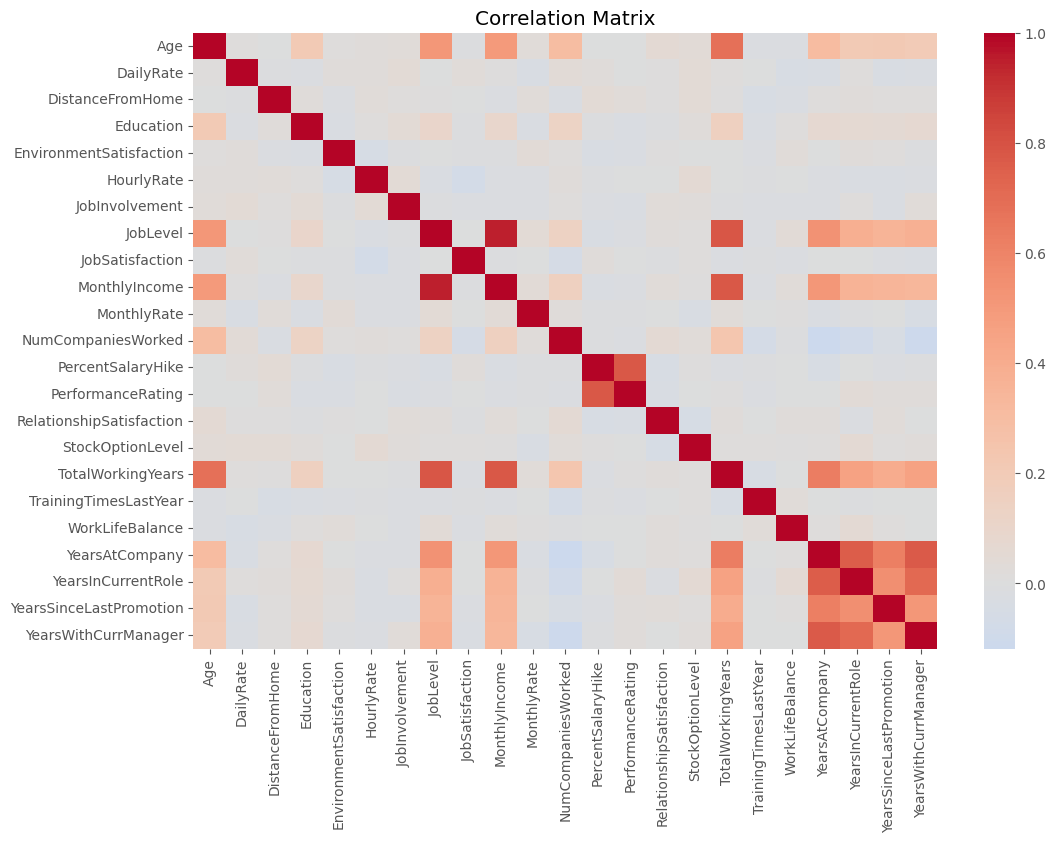

In [54]:
plt.figure(figsize=(12,8))

sns.heatmap(
    numeric_df.corr(),
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix")
plt.show()

## Section 11 — Top Numeric Correlations with Attrition

Since Attrition is text, first we create a temporary numeric version:

In [55]:
df["Attrition Numeric"] = df["Attrition"].map({
    "No":0,
    "Yes":1
})

In [56]:
corr = (
    df.select_dtypes(include=np.number)
      .corr()["Attrition Numeric"]
      .sort_values(ascending=False)
)

corr

Attrition Numeric           1.000000
DistanceFromHome            0.077924
NumCompaniesWorked          0.043494
MonthlyRate                 0.015170
PerformanceRating           0.002889
HourlyRate                 -0.006846
PercentSalaryHike          -0.013478
Education                  -0.031373
YearsSinceLastPromotion    -0.033019
RelationshipSatisfaction   -0.045872
DailyRate                  -0.056652
TrainingTimesLastYear      -0.059478
WorkLifeBalance            -0.063939
EnvironmentSatisfaction    -0.103369
JobSatisfaction            -0.103481
JobInvolvement             -0.130016
YearsAtCompany             -0.134392
StockOptionLevel           -0.137145
YearsWithCurrManager       -0.156199
Age                        -0.159205
MonthlyIncome              -0.159840
YearsInCurrentRole         -0.160545
JobLevel                   -0.169105
TotalWorkingYears          -0.171063
Name: Attrition Numeric, dtype: float64

## Section 12 — Boxplots

Age

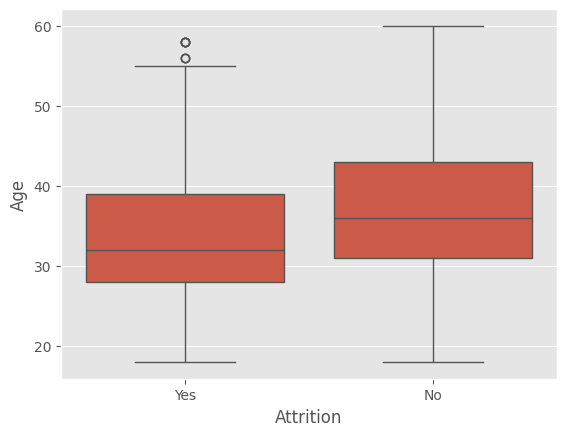

In [57]:
sns.boxplot(
    data=df,
    x="Attrition",
    y="Age"
)

plt.show()

Monthly Income

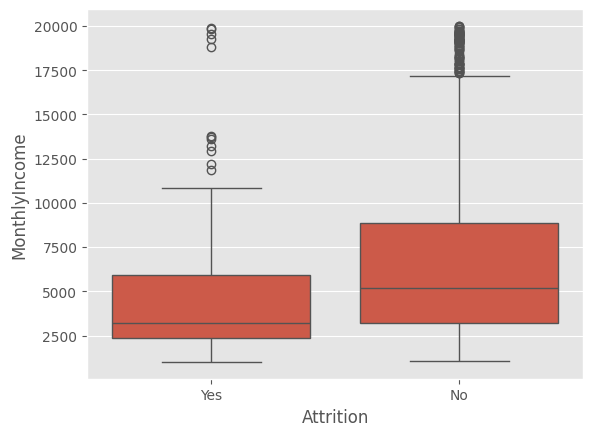

In [58]:
sns.boxplot(
    data=df,
    x="Attrition",
    y="MonthlyIncome"
)

plt.show()

Years at Company

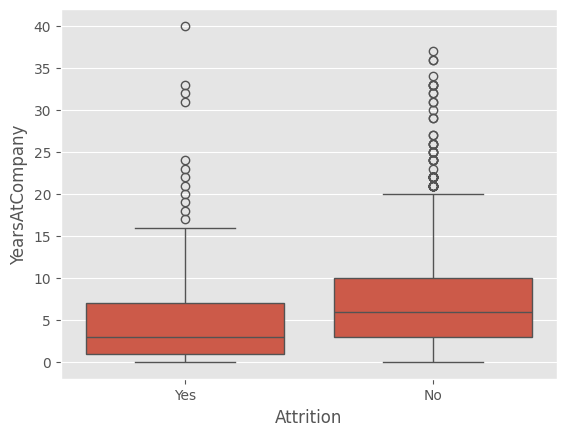

In [59]:
sns.boxplot(
    data=df,
    x="Attrition",
    y="YearsAtCompany"
)

plt.show()

## Section 13 — Saving Again

In [60]:
df.to_csv(
    "../data/processed/clean_hr_attrition.csv",
    index=False
)

## Machine Learning

Predicting whether an employee will leave the company.

Step 1 — Importing ML Libraries

In [61]:
from sklearn.model_selection import train_test_split

from sklearn.preprocessing import LabelEncoder

from sklearn.linear_model import LogisticRegression

from sklearn.tree import DecisionTreeClassifier

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

Step 2 — Encoding Categorical Variables.
Machine learning models require numerical inputs.

In [62]:
from sklearn.preprocessing import LabelEncoder

df_ml = df.copy()

label_encoder = LabelEncoder()

for col in df_ml.select_dtypes(include=["object", "category"]).columns:
    df_ml[col] = label_encoder.fit_transform(df_ml[col])

In [63]:
df_ml.dtypes

Age                         int64
Attrition                   int32
BusinessTravel              int32
DailyRate                   int64
Department                  int32
DistanceFromHome            int64
Education                   int64
EducationField              int32
EnvironmentSatisfaction     int64
Gender                      int32
HourlyRate                  int64
JobInvolvement              int64
JobLevel                    int64
JobRole                     int32
JobSatisfaction             int64
MaritalStatus               int32
MonthlyIncome               int64
MonthlyRate                 int64
NumCompaniesWorked          int64
OverTime                    int32
PercentSalaryHike           int64
PerformanceRating           int64
RelationshipSatisfaction    int64
StockOptionLevel            int64
TotalWorkingYears           int64
TrainingTimesLastYear       int64
WorkLifeBalance             int64
YearsAtCompany              int64
YearsInCurrentRole          int64
YearsSinceLast

Step 3 — Preparing Features

In [64]:
y = df_ml["Attrition"]

X = df_ml.drop(
    columns=[
        "Attrition",
        "Attrition Numeric"
    ]
)

Step 4 — Train/Test Split

In [65]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [66]:
X_train.shape

(1176, 34)

In [67]:
X_test.shape

(294, 34)

Step 5 — Logistic Regression

In [68]:
log_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

log_model.fit(X_train, y_train)

pred_log = log_model.predict(X_test)

c:\Users\User\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Metrics

In [69]:
print("Accuracy:", accuracy_score(y_test, pred_log))
print("Precision:", precision_score(y_test, pred_log))
print("Recall:", recall_score(y_test, pred_log))
print("F1:", f1_score(y_test, pred_log))
print("ROC AUC:", roc_auc_score(y_test, pred_log))

Accuracy: 0.8639455782312925
Precision: 1.0
Recall: 0.14893617021276595
F1: 0.25925925925925924
ROC AUC: 0.574468085106383


Classification Report

In [70]:
print(classification_report(y_test, pred_log))

              precision    recall  f1-score   support

           0       0.86      1.00      0.93       247
           1       1.00      0.15      0.26        47

    accuracy                           0.86       294
   macro avg       0.93      0.57      0.59       294
weighted avg       0.88      0.86      0.82       294



Confusion matrix

In [71]:
confusion_matrix(y_test, pred_log)

array([[247,   0],
       [ 40,   7]], dtype=int64)

## Step 6 — Decision Tree

In [72]:
tree = DecisionTreeClassifier(
    random_state=42,
    max_depth=5
)

tree.fit(X_train, y_train)

pred_tree = tree.predict(X_test)

In [73]:
print("Accuracy:", accuracy_score(y_test, pred_tree))
print("Precision:", precision_score(y_test, pred_tree))
print("Recall:", recall_score(y_test, pred_tree))
print("F1:", f1_score(y_test, pred_tree))
print("ROC AUC:", roc_auc_score(y_test, pred_tree))

Accuracy: 0.8469387755102041
Precision: 0.5625
Recall: 0.19148936170212766
F1: 0.2857142857142857
ROC AUC: 0.5815746403652338


In [74]:
print(classification_report(y_test, pred_tree))

              precision    recall  f1-score   support

           0       0.86      0.97      0.91       247
           1       0.56      0.19      0.29        47

    accuracy                           0.85       294
   macro avg       0.71      0.58      0.60       294
weighted avg       0.82      0.85      0.81       294



In [75]:
confusion_matrix(y_test, pred_tree)

array([[240,   7],
       [ 38,   9]], dtype=int64)

## Step 7 — Random Forest

In [76]:
forest = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

forest.fit(X_train, y_train)

pred_forest = forest.predict(X_test)

In [77]:
print("Accuracy:", accuracy_score(y_test, pred_forest))
print("Precision:", precision_score(y_test, pred_forest))
print("Recall:", recall_score(y_test, pred_forest))
print("F1:", f1_score(y_test, pred_forest))
print("ROC AUC:", roc_auc_score(y_test, pred_forest))

Accuracy: 0.8299319727891157
Precision: 0.36363636363636365
Recall: 0.0851063829787234
F1: 0.13793103448275862
ROC AUC: 0.5283831510035317


In [78]:
print(classification_report(y_test, pred_forest))

              precision    recall  f1-score   support

           0       0.85      0.97      0.91       247
           1       0.36      0.09      0.14        47

    accuracy                           0.83       294
   macro avg       0.61      0.53      0.52       294
weighted avg       0.77      0.83      0.78       294



In [79]:
confusion_matrix(y_test, pred_forest)

array([[240,   7],
       [ 43,   4]], dtype=int64)

## Step 8 — Comparing Models

In [80]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "Accuracy": [
        accuracy_score(y_test, pred_log),
        accuracy_score(y_test, pred_tree),
        accuracy_score(y_test, pred_forest)
    ],
    "Precision": [
        precision_score(y_test, pred_log),
        precision_score(y_test, pred_tree),
        precision_score(y_test, pred_forest)
    ],
    "Recall": [
        recall_score(y_test, pred_log),
        recall_score(y_test, pred_tree),
        recall_score(y_test, pred_forest)
    ],
    "F1 Score": [
        f1_score(y_test, pred_log),
        f1_score(y_test, pred_tree),
        f1_score(y_test, pred_forest)
    ],
    "ROC AUC": [
        roc_auc_score(y_test, pred_log),
        roc_auc_score(y_test, pred_tree),
        roc_auc_score(y_test, pred_forest)
    ]
})

results

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Logistic Regression,0.863946,1.000000,0.148936,0.259259,0.574468
1,Decision Tree,0.846939,0.562500,0.191489,0.285714,0.581575
2,Random Forest,0.829932,0.363636,0.085106,0.137931,0.528383


## Step 9 — Feature Importance (Random Forest)

In [81]:
importance = pd.Series(
    forest.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

importance.head(15)

MonthlyIncome              0.069965
Age                        0.062204
DailyRate                  0.054795
TotalWorkingYears          0.054562
MonthlyRate                0.046620
DistanceFromHome           0.046467
HourlyRate                 0.045546
YearsAtCompany             0.042815
OverTime                   0.037341
NumCompaniesWorked         0.035415
PercentSalaryHike          0.034769
YearsWithCurrManager       0.031379
JobRole                    0.029012
EnvironmentSatisfaction    0.027825
StockOptionLevel           0.027484
dtype: float64

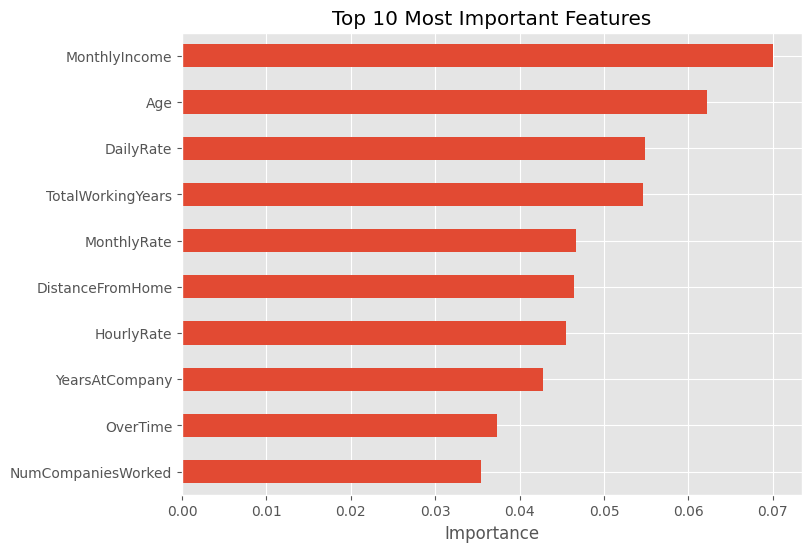

In [82]:
plt.figure(figsize=(8,6))

importance.head(10).sort_values().plot(kind="barh")

plt.title("Top 10 Most Important Features")

plt.xlabel("Importance")

plt.show()

## Step 10 — Save the Model Results

In [83]:
results.to_csv(
    "../outputs/model_comparison.csv",
    index=False
)

## Improving the Machine Learning Pipeline

## Step 1 — Creating a fresh ML dataset

In [84]:
df_ml = df.copy()

## Step 2 — One-Hot Encoding the categorical variables

In [85]:
df_ml = pd.get_dummies(
    df_ml,
    drop_first=True,
    dtype=int
)

## Step 3 — Checking the dataframe

In [86]:
df_ml.head()

,Age,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,...,Age Group_51-60,Income Group_Lower-Middle,Income Group_Upper-Middle,Income Group_High,Tenure Group_3-5,Tenure Group_6-10,Tenure Group_10+,Experience Group_6-10,Experience Group_11-20,Experience Group_20+
0,41,1102,1,2,2,94,3,2,4,5993,...,0,0,1,0,0,1,0,1,0,0
1,49,279,8,1,3,61,2,2,2,5130,...,0,0,1,0,0,1,0,1,0,0
2,37,1373,2,2,4,92,2,1,3,2090,...,0,0,0,0,0,0,0,1,0,0
3,33,1392,3,4,4,56,3,1,3,2909,...,0,0,0,0,0,1,0,1,0,0
4,27,591,2,1,1,40,3,1,2,3468,...,0,1,0,0,0,0,0,1,0,0


In [87]:
df_ml.columns.tolist()

['Age',
 'DailyRate',
 'DistanceFromHome',
 'Education',
 'EnvironmentSatisfaction',
 'HourlyRate',
 'JobInvolvement',
 'JobLevel',
 'JobSatisfaction',
 'MonthlyIncome',
 'MonthlyRate',
 'NumCompaniesWorked',
 'PercentSalaryHike',
 'PerformanceRating',
 'RelationshipSatisfaction',
 'StockOptionLevel',
 'TotalWorkingYears',
 'TrainingTimesLastYear',
 'WorkLifeBalance',
 'YearsAtCompany',
 'YearsInCurrentRole',
 'YearsSinceLastPromotion',
 'YearsWithCurrManager',
 'Attrition Numeric',
 'Attrition_Yes',
 'BusinessTravel_Travel_Frequently',
 'BusinessTravel_Travel_Rarely',
 'Department_Research & Development',
 'Department_Sales',
 'EducationField_Life Sciences',
 'EducationField_Marketing',
 'EducationField_Medical',
 'EducationField_Other',
 'EducationField_Technical Degree',
 'Gender_Male',
 'JobRole_Human Resources',
 'JobRole_Laboratory Technician',
 'JobRole_Manager',
 'JobRole_Manufacturing Director',
 'JobRole_Research Director',
 'JobRole_Research Scientist',
 'JobRole_Sales Execu

In [88]:
df_ml.shape

(1470, 58)

## Step 4 — Preparing X and y

In [89]:
y = df_ml["Attrition_Yes"]

X = df_ml.drop(
    columns=[
        "Attrition_Yes",
        "Attrition Numeric"
    ]
)

## Step 5 — Train/Test Split

In [90]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

## Step 6 — Training the three models again

In [91]:
log_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

log_model.fit(X_train, y_train)

pred_log = log_model.predict(X_test)

c:\Users\User\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [92]:
print("Accuracy:", accuracy_score(y_test, pred_log))
print("Precision:", precision_score(y_test, pred_log))
print("Recall:", recall_score(y_test, pred_log))
print("F1:", f1_score(y_test, pred_log))
print("ROC AUC:", roc_auc_score(y_test, pred_log))

Accuracy: 0.8809523809523809
Precision: 0.875
Recall: 0.2978723404255319
F1: 0.4444444444444444
ROC AUC: 0.6448875872168146


In [93]:
tree = DecisionTreeClassifier(
    random_state=42,
    max_depth=5
)

tree.fit(X_train, y_train)

pred_tree = tree.predict(X_test)

In [94]:
print("Accuracy:", accuracy_score(y_test, pred_tree))
print("Precision:", precision_score(y_test, pred_tree))
print("Recall:", recall_score(y_test, pred_tree))
print("F1:", f1_score(y_test, pred_tree))
print("ROC AUC:", roc_auc_score(y_test, pred_tree))

Accuracy: 0.8367346938775511
Precision: 0.47058823529411764
Recall: 0.1702127659574468
F1: 0.25
ROC AUC: 0.566887759496942


In [95]:
forest = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

forest.fit(X_train, y_train)

pred_forest = forest.predict(X_test)

In [96]:
print("Accuracy:", accuracy_score(y_test, pred_forest))
print("Precision:", precision_score(y_test, pred_forest))
print("Recall:", recall_score(y_test, pred_forest))
print("F1:", f1_score(y_test, pred_forest))
print("ROC AUC:", roc_auc_score(y_test, pred_forest))

Accuracy: 0.8333333333333334
Precision: 0.4
Recall: 0.0851063829787234
F1: 0.14035087719298245
ROC AUC: 0.5304074425015074


In [97]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "Accuracy": [
        accuracy_score(y_test, pred_log),
        accuracy_score(y_test, pred_tree),
        accuracy_score(y_test, pred_forest)
    ],
    "Precision": [
        precision_score(y_test, pred_log),
        precision_score(y_test, pred_tree),
        precision_score(y_test, pred_forest)
    ],
    "Recall": [
        recall_score(y_test, pred_log),
        recall_score(y_test, pred_tree),
        recall_score(y_test, pred_forest)
    ],
    "F1 Score": [
        f1_score(y_test, pred_log),
        f1_score(y_test, pred_tree),
        f1_score(y_test, pred_forest)
    ],
    "ROC AUC": [
        roc_auc_score(y_test, pred_log),
        roc_auc_score(y_test, pred_tree),
        roc_auc_score(y_test, pred_forest)
    ]
})

results

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Logistic Regression,0.880952,0.875000,0.297872,0.444444,0.644888
1,Decision Tree,0.836735,0.470588,0.170213,0.250000,0.566888
2,Random Forest,0.833333,0.400000,0.085106,0.140351,0.530407


## Step 7 - Feature Engineering

In [98]:
importance = pd.Series(
    forest.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

importance.head(15)

MonthlyIncome              0.070498
Age                        0.057385
DailyRate                  0.053056
TotalWorkingYears          0.052247
HourlyRate                 0.044966
MonthlyRate                0.042966
DistanceFromHome           0.041660
YearsAtCompany             0.039084
OverTime_Yes               0.038475
YearsWithCurrManager       0.034511
NumCompaniesWorked         0.032746
PercentSalaryHike          0.032406
EnvironmentSatisfaction    0.027436
WorkLifeBalance            0.026097
YearsInCurrentRole         0.025285
dtype: float64

## One Final Improvement

Handling Class Imbalance:
After observing poor recall due to class imbalance, I am retraining the models using balanced class weights and comparing the trade-offs between overall accuracy and identifying employees at risk of leaving.

In [99]:
df_ml = df.copy()

In [100]:
df_ml = pd.get_dummies(
    df_ml,
    drop_first=True,
    dtype=int
)

In [101]:
y = df_ml["Attrition_Yes"]

X = df_ml.drop(
    columns=[
        "Attrition_Yes",
        "Attrition Numeric"
    ]
)

In [102]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [103]:
log_model = LogisticRegression(
    max_iter=1000,
    random_state=42,
    class_weight="balanced"
)

log_model.fit(X_train, y_train)

c:\Users\User\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

In [104]:
tree_model = DecisionTreeClassifier(
    random_state=42,
    class_weight="balanced"
)

tree_model.fit(X_train, y_train)

DecisionTreeClassifier(class_weight='balanced', random_state=42)

In [105]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced"
)

rf_model.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', n_estimators=200,
                       random_state=42)

Step 1: Generate predictions

In [106]:
pred_log_bal = log_model.predict(X_test)

pred_tree_bal = tree_model.predict(X_test)

pred_rf_bal = rf_model.predict(X_test)

Step 2: Evaluating each model

In [107]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)

In [108]:
print("Accuracy:", accuracy_score(y_test, pred_log_bal))
print("Precision:", precision_score(y_test, pred_log_bal))
print("Recall:", recall_score(y_test, pred_log_bal))
print("F1:", f1_score(y_test, pred_log_bal))
print("ROC AUC:", roc_auc_score(y_test, pred_log_bal))

print(confusion_matrix(y_test, pred_log_bal))

Accuracy: 0.7312925170068028
Precision: 0.336734693877551
Recall: 0.7021276595744681
F1: 0.45517241379310347
ROC AUC: 0.7194848824188131
[[182  65]
 [ 14  33]]


In [109]:
print("Accuracy:", accuracy_score(y_test, pred_tree_bal))
print("Precision:", precision_score(y_test, pred_tree_bal))
print("Recall:", recall_score(y_test, pred_tree_bal))
print("F1:", f1_score(y_test, pred_tree_bal))
print("ROC AUC:", roc_auc_score(y_test, pred_tree_bal))

print(confusion_matrix(y_test, pred_tree_bal))

Accuracy: 0.7687074829931972
Precision: 0.2765957446808511
Recall: 0.2765957446808511
F1: 0.2765957446808511
ROC AUC: 0.5694719614092515
[[213  34]
 [ 34  13]]


In [110]:
print("Accuracy:", accuracy_score(y_test, pred_rf_bal))
print("Precision:", precision_score(y_test, pred_rf_bal))
print("Recall:", recall_score(y_test, pred_rf_bal))
print("F1:", f1_score(y_test, pred_rf_bal))
print("ROC AUC:", roc_auc_score(y_test, pred_rf_bal))

print(confusion_matrix(y_test, pred_rf_bal))

Accuracy: 0.8333333333333334
Precision: 0.375
Recall: 0.06382978723404255
F1: 0.10909090909090909
ROC AUC: 0.5217934361271427
[[242   5]
 [ 44   3]]


In [136]:
results = pd.DataFrame({

    "Model": [
        "Logistic Regression (Balanced)",
        "Decision Tree (Balanced)",
        "Random Forest (Balanced)"
    ],

    "Accuracy": [
        0.731293,
        0.768707,
        0.833333
    ],

    "Precision": [
        0.336735,
        0.276596,
        0.375000
    ],

    "Recall": [
        0.702128,
        0.276596,
        0.063830
    ],

    "F1 Score": [
        0.455172,
        0.276596,
        0.109091
    ],

    "ROC AUC": [
        0.719485,
        0.569472,
        0.521793
    ]

})

results.to_csv(
    "../outputs/model_comparison.csv",
    index=False
)

## Basic Queries

In [112]:
import sqlite3

conn = sqlite3.connect("../data/processed/hr_attrition.db")

df.to_sql(
    "hr_attrition",
    conn,
    if_exists="replace",
    index=False
)

print("Database created successfully!")

Database created successfully!


In [113]:
query = """
SELECT
    COUNT(*) AS total_employees
FROM hr_attrition;
"""

pd.read_sql(query, conn)

,total_employees
0,1470


In [114]:
query = """
SELECT
    AVG(Age) AS average_age
FROM hr_attrition;
"""

pd.read_sql(query, conn)

,average_age
0,36.92381


In [115]:
query = """
SELECT
    AVG(MonthlyIncome) AS average_income
FROM hr_attrition;
"""

pd.read_sql(query, conn)

,average_income
0,6502.931293


In [116]:
query = """
SELECT
    Attrition,
    COUNT(*) AS employees
FROM hr_attrition
GROUP BY Attrition;
"""

pd.read_sql(query, conn)

,Attrition,employees
0,No,1233
1,Yes,237


In [117]:
query = """
SELECT
    Department,
    COUNT(*) AS employees
FROM hr_attrition
GROUP BY Department;
"""

pd.read_sql(query, conn)

,Department,employees
0,Human Resources,63
1,Research & Development,961
2,Sales,446


In [118]:
query = """
SELECT
    JobRole,
    COUNT(*) AS employees
FROM hr_attrition
GROUP BY JobRole
ORDER BY employees DESC;
"""

pd.read_sql(query, conn)

,JobRole,employees
0,Sales Executive,326
1,Research Scientist,292
2,Laboratory Technician,259
3,Manufacturing Director,145
4,Healthcare Representative,131
5,Manager,102
6,Sales Representative,83
7,Research Director,80
8,Human Resources,52


In [119]:
query = """
SELECT
    OverTime,
    COUNT(*) AS employees
FROM hr_attrition
GROUP BY OverTime;
"""

pd.read_sql(query, conn)

,OverTime,employees
0,No,1054
1,Yes,416


## Advanced Queries

In [120]:
query = """
SELECT
    Department,
    COUNT(*) AS total,
    SUM(CASE WHEN Attrition='Yes' THEN 1 ELSE 0 END) AS attrition,
    ROUND(
        100.0 *
        SUM(CASE WHEN Attrition='Yes' THEN 1 ELSE 0 END) /
        COUNT(*),
        2
    ) AS attrition_rate
FROM hr_attrition
GROUP BY Department
ORDER BY attrition_rate DESC;
"""

pd.read_sql(query, conn)

,Department,total,attrition,attrition_rate
0,Sales,446,92,20.63
1,Human Resources,63,12,19.05
2,Research & Development,961,133,13.84


In [121]:
query = """
SELECT
    JobRole,
    COUNT(*) total,
    SUM(CASE WHEN Attrition='Yes' THEN 1 ELSE 0 END) attrition,
    ROUND(
        100.0*
        SUM(CASE WHEN Attrition='Yes' THEN 1 ELSE 0 END)/COUNT(*),
        2
    ) attrition_rate
FROM hr_attrition
GROUP BY JobRole
ORDER BY attrition_rate DESC;
"""

pd.read_sql(query, conn)

,JobRole,total,attrition,attrition_rate
0,Sales Representative,83,33,39.76
1,Laboratory Technician,259,62,23.94
2,Human Resources,52,12,23.08
3,Sales Executive,326,57,17.48
4,Research Scientist,292,47,16.10
5,Manufacturing Director,145,10,6.90
6,Healthcare Representative,131,9,6.87
7,Manager,102,5,4.90
8,Research Director,80,2,2.50


In [122]:
query = """
SELECT
    Attrition,
    AVG(MonthlyIncome)
FROM hr_attrition
GROUP BY Attrition;
"""

pd.read_sql(query, conn)

,Attrition,AVG(MonthlyIncome)
0,No,6832.739659
1,Yes,4787.092827


In [123]:
query = """
SELECT
    Attrition,
    AVG(YearsAtCompany)
FROM hr_attrition
GROUP BY Attrition;
"""

pd.read_sql(query, conn)

,Attrition,AVG(YearsAtCompany)
0,No,7.369019
1,Yes,5.130802


In [124]:
query = """
SELECT
    Attrition,
    AVG(TotalWorkingYears)
FROM hr_attrition
GROUP BY Attrition;
"""

pd.read_sql(query, conn)

,Attrition,AVG(TotalWorkingYears)
0,No,11.862936
1,Yes,8.244726


## Model Metrics

In [125]:
cursor = conn.cursor()

In [126]:
cursor.execute("""
DROP TABLE IF EXISTS model_metrics
""")

In [127]:
cursor.execute("""
CREATE TABLE model_metrics (

Model TEXT,

Accuracy REAL,

Precision REAL,

Recall REAL,

F1 REAL,

ROC_AUC REAL

)
""")

In [128]:
cursor.executemany("""
INSERT INTO model_metrics
VALUES (?,?,?,?,?,?)
""",[
("Logistic Regression",0.864,1.000,0.149,0.259,0.574),
("Logistic Regression (One-Hot)",0.881,0.875,0.298,0.444,0.645),
("Logistic Regression (Balanced)",0.731,0.337,0.702,0.455,0.719),
("Decision Tree",0.837,0.471,0.170,0.250,0.567),
("Random Forest",0.833,0.400,0.085,0.140,0.530)
])

In [129]:
conn.commit()

In [130]:
pd.read_sql("""
SELECT *
FROM model_metrics
ORDER BY ROC_AUC DESC
""", conn)

,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,Logistic Regression (Balanced),0.731,0.337,0.702,0.455,0.719
1,Logistic Regression (One-Hot),0.881,0.875,0.298,0.444,0.645
2,Logistic Regression,0.864,1.000,0.149,0.259,0.574
3,Decision Tree,0.837,0.471,0.170,0.250,0.567
4,Random Forest,0.833,0.400,0.085,0.140,0.530


In [131]:
df.to_csv(
    "../data/processed/clean_hr_attrition.csv",
    index=False
)

In [132]:
rf_bal = RandomForestClassifier(
    random_state=42,
    class_weight="balanced"
)

rf_bal.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', random_state=42)

In [133]:
import pandas as pd

cm = pd.DataFrame(
    [[182,65],
     [14,33]],
    index=["Actual Stay","Actual Leave"],
    columns=["Predicted Stay","Predicted Leave"]
)

cm.to_csv(
    "../outputs/confusion_matrix.csv"
)

In [134]:
feature_importance_df = importance.reset_index()

feature_importance_df.columns = [
    "Feature",
    "Importance"
]

feature_importance_df.to_csv(
    "../outputs/feature_importance.csv",
    index=False
)

print("feature_importance.csv saved successfully!")

feature_importance.csv saved successfully!
